# Step 7: Spherical JAM Aperture Comparison

这个 notebook 使用 **完全球对称** 的 JAM 建模来和 WFI2033 文献中的中心速度弥散比较。

## 关键选择

- 使用 `jampy.sph.jam_sph_proj`，不再使用 `jam_axi_proj`；
- tracer light 使用 stage3 lens-light MGE 的 `amp_lens` 和 `sigma_lens`，并转换为 JAM 需要的 peak surface brightness；
- mass profile 使用 circularized EPL 的 surface density，再用 `mge_fit_1d` 拟合并转换为 JAM 需要的 peak surface density；
- 不再使用任何 tracer ellipticity 或 mass ellipticity；
- anisotropy 使用 Osipkov-Merritt，并用 `rani` 直接传给 `jam_sph_proj`。

## 文献设定

- 观测量：`250 ± 19 km/s`
- aperture：`1.8" × 1.8"` square aperture
- seeing：`1.0"` FWHM
- lens/source redshift：`z_l = 0.6575`, `z_s = 1.662`
- anisotropy prior：`r_ani / r_eff ~ U(0.5, 5.0)`，其中 `r_eff = 1.41"`

## 当前 notebook 的用途

- 本地只做 smoke test；
- 最终 2000-sample 的正式 analysis 仍建议在远端运行。


In [1]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

from pathlib import Path
import io
import contextlib
import warnings
warnings.filterwarnings('ignore', message='Pandas requires version', category=UserWarning)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import corner

from astropy.cosmology import FlatLambdaCDM
from astropy.constants import c, G
from mgefit.mge_fit_1d import mge_fit_1d
from jampy.sph.jam_sph_proj import jam_sph_proj

SEED = 42
rng = np.random.default_rng(SEED)

POSTERIOR_PATH = Path('../../WFI2033_psf_correct_all_ss=2_onegibbs.nc')

N_SAMPLES = 2000
SMOKE_TEST = True
N_SAMPLES_SMOKE = 8
N_RUN = N_SAMPLES_SMOKE if SMOKE_TEST else N_SAMPLES

Z_LENS = 0.6575
Z_SOURCE = 1.662
SIGMA_OBS_KMS = 250.0
SIGMA_OBS_ERR_KMS = 19.0
APERTURE_SIZE_ARCSEC = 1.8
SEEING_FWHM_ARCSEC = 1.0
SIGMAPSF_ARCSEC = SEEING_FWHM_ARCSEC / 2.355
JAM_STEP_ARCSEC = 0.03

R_EFF_PRIOR_ARCSEC = 1.41
RANI_OVER_REFF_LOW = 0.5
RANI_OVER_REFF_HIGH = 5.0

cosmo = FlatLambdaCDM(H0=70.0, Om0=0.3)
Dd_mpc = cosmo.angular_diameter_distance(Z_LENS).value
Ds_mpc = cosmo.angular_diameter_distance(Z_SOURCE).value
Dds_mpc = cosmo.angular_diameter_distance_z1z2(Z_LENS, Z_SOURCE).value

SIGMA_CRIT_MSUN_PC2 = (
    c.to('km/s')**2 / (4.0 * np.pi * G.to('pc km2 / (Msun s2)'))
    * (Ds_mpc / (Dd_mpc * Dds_mpc)) / 1e6
).value

print(f'SMOKE_TEST = {SMOKE_TEST}')
print(f'N_RUN = {N_RUN}')
print(f'z_l = {Z_LENS}, z_s = {Z_SOURCE}')
print(f'Sigma_crit = {SIGMA_CRIT_MSUN_PC2:.3f} Msun/pc^2')
print(f'Dd = {Dd_mpc:.3f} Mpc')
print(f'Observed sigma = {SIGMA_OBS_KMS:.1f} +/- {SIGMA_OBS_ERR_KMS:.1f} km/s')


SMOKE_TEST = True
N_RUN = 8
z_l = 0.6575, z_s = 1.662
Sigma_crit = 2372.018 Msun/pc^2
Dd = 1436.304 Mpc
Observed sigma = 250.0 +/- 19.0 km/s


In [2]:
# Spherical tracer MGE: 使用 stage3 lens-light 的 integrated flux 和 sigma。
# JAM 需要的是每个 Gaussian 的 peak surface brightness，
# 因此这里把 herculens 的 amp_lens 转成 surf_lum = amp_lens / (2*pi*sigma^2)。

amp_lens = np.array([
    2.37832050e-10, 8.69753952e-10, 5.06877124e-09, 1.89731325e-08,
    8.15798001e-08, 3.48132735e-07, 4.92368916e-07, 8.46268107e-07,
    9.97287044e+00, 4.15598295e-05, 1.65836991e+02, 6.56911322e-03,
    2.43416112e+02, 6.13040523e+02, 2.46551956e+03,
], dtype=float)

sigma_lens = np.array([
    1.45202164e-05, 3.15551548e-05, 6.83630417e-05, 1.47285364e-04,
    3.15022396e-04, 6.67243318e-04, 1.43425653e-03, 3.09753498e-03,
    9.99327311e-03, 1.43776796e-02, 4.07272766e-02, 6.64166465e-02,
    1.00080961e-01, 2.54284370e-01, 8.99154715e-01,
], dtype=float)

surf_lum = amp_lens / (2.0 * np.pi * sigma_lens**2)


In [3]:
def circularized_epl_kappa(R_arcsec, theta_E_arcsec, gamma_slope):
    return 0.5 * (3.0 - gamma_slope) * (R_arcsec / theta_E_arcsec) ** (1.0 - gamma_slope)


def fit_epl_surface_density_mge(theta_E_arcsec, gamma_slope, ngauss=16):
    r_arcsec = np.geomspace(1e-3, 20.0 * theta_E_arcsec, 400)
    kappa = circularized_epl_kappa(r_arcsec, theta_E_arcsec, gamma_slope)
    sigma_surface = kappa * SIGMA_CRIT_MSUN_PC2
    with contextlib.redirect_stdout(io.StringIO()):
        mge_fit = mge_fit_1d(r_arcsec, sigma_surface, ngauss=ngauss, quiet=True, plot=False)
    sigma_pot = np.asarray(mge_fit.sol[1], dtype=float)
    # mge_fit_1d.sol[0] is 1D total_counts; JAM expects peak surface density.
    surf_pot = np.asarray(mge_fit.sol[0], dtype=float) / (np.sqrt(2.0 * np.pi) * sigma_pot)
    return surf_pot, sigma_pot


def draw_rani_arcsec(size):
    return rng.uniform(RANI_OVER_REFF_LOW, RANI_OVER_REFF_HIGH, size=size) * R_EFF_PRIOR_ARCSEC


In [4]:
posterior = xr.open_dataset(POSTERIOR_PATH, group='posterior', engine='h5netcdf')
posterior = posterior[['theta_E_1', 'gamma_1']]
posterior_stack = posterior.stack(sample=('chain', 'draw'))

n_total = posterior_stack.sizes['sample']
chosen = rng.choice(n_total, size=N_SAMPLES, replace=False)
chosen_run = chosen[:N_RUN]
posterior_run = posterior_stack.isel(sample=chosen_run).load()

print(f'total posterior samples available = {n_total}')
print(f'selected for final remote analysis = {N_SAMPLES}')
print(f'run in this local notebook = {len(chosen_run)}')


total posterior samples available = 48000
selected for final remote analysis = 2000
run in this local notebook = 8


In [5]:
r_ani_samples = draw_rani_arcsec(len(chosen_run))

sigma_ap_samples = []
theta_E_samples = []
gamma_samples = []

for i in range(len(chosen_run)):
    theta_E_i = float(np.asarray(posterior_run['theta_E_1'].isel(sample=i).values).reshape(-1)[0])
    gamma_i = float(np.asarray(posterior_run['gamma_1'].isel(sample=i).values).reshape(-1)[0])

    surf_pot_i, sigma_pot_i = fit_epl_surface_density_mge(
        theta_E_arcsec=theta_E_i,
        gamma_slope=gamma_i,
        ngauss=16,
    )

    jam_i = jam_sph_proj(
        surf_lum,
        sigma_lens,
        surf_pot_i,
        sigma_pot_i,
        mbh=0.0,
        distance=Dd_mpc,
        rad=np.array([0.0]),
        rani=r_ani_samples[i],
        sigmapsf=SIGMAPSF_ARCSEC,
        pixsize=APERTURE_SIZE_ARCSEC,
        step=JAM_STEP_ARCSEC,
        plot=False,
        quiet=True,
        tensor='los',
    )

    sigma_ap_samples.append(float(np.asarray(jam_i.model)[0]))
    theta_E_samples.append(theta_E_i)
    gamma_samples.append(gamma_i)

sigma_ap_samples = np.asarray(sigma_ap_samples)
theta_E_samples = np.asarray(theta_E_samples)
gamma_samples = np.asarray(gamma_samples)

print('theta_E range:', float(theta_E_samples.min()), float(theta_E_samples.max()))
print('gamma range:', float(gamma_samples.min()), float(gamma_samples.max()))
print('r_ani range [arcsec]:', float(r_ani_samples.min()), float(r_ani_samples.max()))
print('sigma_ap range [km/s]:', float(sigma_ap_samples.min()), float(sigma_ap_samples.max()))


theta_E range: 1.0244519455718166 1.0323226507350056
gamma range: 1.8232402397892438 1.8367246861348516
r_ani range [arcsec]: 1.0987904109972848 6.554153796233443
sigma_ap range [km/s]: 217.20212890658425 229.38986979074588


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_70092/3418586586.py:19: SyntaxWarning: invalid escape sequence '\s'
  label='paper 1$\sigma$'


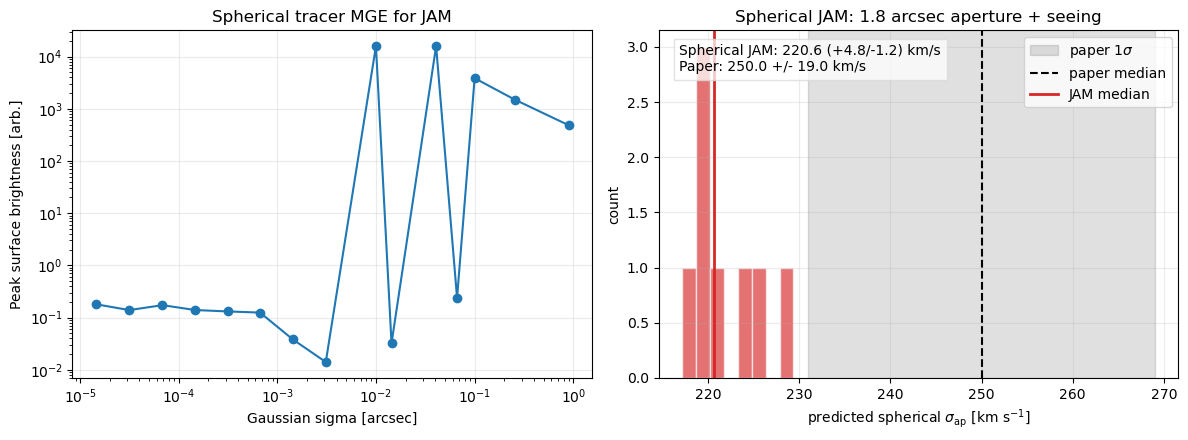

In [6]:
sigma_ap_p16, sigma_ap_p50, sigma_ap_p84 = np.percentile(sigma_ap_samples, [16, 50, 84])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(sigma_lens, surf_lum, 'o-', lw=1.5, color='tab:blue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Gaussian sigma [arcsec]')
axes[0].set_ylabel('Peak surface brightness [arb.]')
axes[0].set_title('Spherical tracer MGE for JAM')
axes[0].grid(alpha=0.25)

axes[1].hist(sigma_ap_samples, bins=min(12, len(sigma_ap_samples)), color='tab:red', alpha=0.65, edgecolor='white')
axes[1].axvspan(
    SIGMA_OBS_KMS - SIGMA_OBS_ERR_KMS,
    SIGMA_OBS_KMS + SIGMA_OBS_ERR_KMS,
    color='k',
    alpha=0.12,
    label='paper 1$\sigma$'
)
axes[1].axvline(SIGMA_OBS_KMS, color='k', lw=1.5, ls='--', label='paper median')
axes[1].axvline(sigma_ap_p50, color='tab:red', lw=2.0, label='JAM median')
axes[1].set_xlabel(r'predicted spherical $\sigma_{\rm ap}$ [km s$^{-1}$]')
axes[1].set_ylabel('count')
axes[1].set_title('Spherical JAM: 1.8 arcsec aperture + seeing')
axes[1].legend()
axes[1].grid(alpha=0.25)

text = (
    f'Spherical JAM: {sigma_ap_p50:.1f} (+{sigma_ap_p84 - sigma_ap_p50:.1f}/-{sigma_ap_p50 - sigma_ap_p16:.1f}) km/s\n'
    f'Paper: {SIGMA_OBS_KMS:.1f} +/- {SIGMA_OBS_ERR_KMS:.1f} km/s'
)
axes[1].text(0.04, 0.96, text, transform=axes[1].transAxes, va='top', ha='left', fontsize=10,
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='0.85'))

plt.tight_layout()
plt.show()


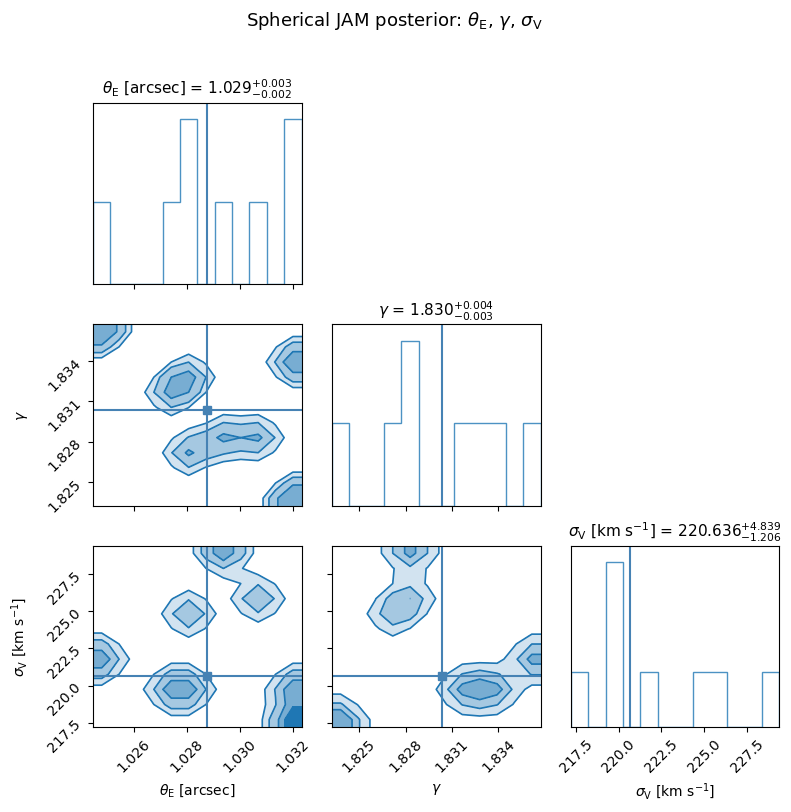

In [7]:
corner_samples = np.column_stack([theta_E_samples, gamma_samples, sigma_ap_samples])
fig = corner.corner(
    corner_samples,
    labels=[r'$\theta_{\rm E}$ [arcsec]', r'$\gamma$', r'$\sigma_{\rm V}$ [km s$^{-1}$]'],
    truths=[np.median(theta_E_samples), np.median(gamma_samples), np.median(sigma_ap_samples)],
    bins=12,
    smooth=0.8,
    color='tab:blue',
    show_titles=True,
    title_fmt='.3f',
    title_kwargs={'fontsize': 11},
    plot_datapoints=True,
    fill_contours=True,
    plot_density=False,
    contour_kwargs={'linewidths': 1.2},
    hist_kwargs={'density': True, 'alpha': 0.8},
    fig=plt.figure(figsize=(8, 8)),
)
fig.suptitle(r'Spherical JAM posterior: $\theta_{\rm E}$, $\gamma$, $\sigma_{\rm V}$', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
sigma_ap_p16, sigma_ap_p50, sigma_ap_p84 = np.percentile(sigma_ap_samples, [16, 50, 84])
delta_sigma = sigma_ap_p50 - SIGMA_OBS_KMS

after_norm = delta_sigma / SIGMA_OBS_ERR_KMS

print(f'Predicted spherical sigma_ap median = {sigma_ap_p50:.2f} km/s')
print(f'Predicted spherical sigma_ap 16-84% = {sigma_ap_p16:.2f} - {sigma_ap_p84:.2f} km/s')
print(f'Observed paper value = {SIGMA_OBS_KMS:.2f} +/- {SIGMA_OBS_ERR_KMS:.2f} km/s')
print(f'Delta (model - paper) = {delta_sigma:.2f} km/s = {after_norm:.2f} sigma_obs')
print('')
print('Notes:')
print('- 这是完全球对称的 JAM 版本，不再包含任何椭率。')
print('- tracer 输入已改为 peak surface brightness，而不是 integrated flux。')
print('- mass MGE 输入也已改为 peak surface density，而不是 mge_fit_1d 的 total_counts。')
print('- anisotropy 通过 Osipkov-Merritt 半径 r_ani 引入。')
print('- 正式远端分析时，把 N_RUN 切换到 2000 即可。')


Predicted spherical sigma_ap median = 220.64 km/s
Predicted spherical sigma_ap 16-84% = 219.43 - 225.47 km/s
Observed paper value = 250.00 +/- 19.00 km/s
Delta (model - paper) = -29.36 km/s = -1.55 sigma_obs

Notes:
- 这是完全球对称的 JAM 版本，不再包含任何椭率。
- tracer 输入已改为 peak surface brightness，而不是 integrated flux。
- mass MGE 输入也已改为 peak surface density，而不是 mge_fit_1d 的 total_counts。
- anisotropy 通过 Osipkov-Merritt 半径 r_ani 引入。
- 正式远端分析时，把 N_RUN 切换到 2000 即可。
